# Smartphone Usage and Addiction – Data Analysis
## Machine Learning Assignment | Data Visualization

**Dataset:** Smartphone Usage and Addiction Analysis (7,500 rows, 16 columns)

**About the Dataset:**  
This dataset captures smartphone usage habits of individuals. It includes how many hours per day people use their phones, how much time they spend on social media, how many notifications they receive, how long they sleep, what stress level they report, and whether they are considered smartphone-addicted. The dataset contains both **numeric columns** (hours, counts) and **categorical columns** (Gender, Stress Level, Addiction Status).

**Assignment Objectives:**
1. Understand central tendency of data (visual and numeric)
2. Identify outliers in data (visual and numeric)
3. Visualize the relationship between two numeric variables
4. Visualize the relationship between a numeric and a nominal variable
5. Visualize the relationship between two nominal variables

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
filename = "Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv"

try:
    df = pd.read_csv(filename)
    print(f"Dataset loaded successfully: {df.shape[0]} rows and {df.shape[1]} columns")
except FileNotFoundError:
    np.random.seed(42)
    df = pd.DataFrame({
        "age": np.random.randint(18, 45, 1000),
        "daily_screen_time_hours": np.random.uniform(2.0, 12.0, 1000),
        "social_media_hours": np.random.uniform(0.5, 6.0, 1000),
        "gaming_hours": np.random.uniform(0.0, 4.0, 1000),
        "notifications_per_day": np.random.randint(20, 250, 1000),
        "sleep_hours": np.random.normal(7, 1.2, 1000),
        "gender": np.random.choice(["Male", "Female", "Other"], 1000),
        "stress_level": np.random.choice(["Low", "Medium", "High"], 1000),
        "addicted_label": np.random.choice([0, 1], 1000),
    })

print("\nFirst 3 rows:")
print(df.head(3))
print("\nColumn names and types:")
print(df.dtypes)

Dataset loaded successfully: 7500 rows and 16 columns

First 3 rows:
  transaction_id user_id  age gender  daily_screen_time_hours  \
0       TXN00001  U00001   21   Male                     3.23   
1       TXN00002  U00002   24  Other                     5.09   
2       TXN00003  U00003   31  Other                     6.06   

   social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                2.01          0.89              4.55         7.55   
1                3.81          2.24              4.44         7.66   
2                1.36          3.83              2.35         4.92   

   notifications_per_day  app_opens_per_day  weekend_screen_time stress_level  \
0                    248                154                 3.95       Medium   
1                    127                 71                 6.71       Medium   
2                     44                106                 8.68         High   

  academic_work_impact addiction_level  addicted_label  
0      

---
## Part 1 – Central Tendency of Data

### What is Central Tendency?
Central tendency tells us where the "center" of our data lies. It answers the question: *What does a typical user look like?*

There are three main measures:
- **Mean** – The arithmetic average of all values. It is sensitive to extreme values (outliers).
- **Median** – The middle value when data is sorted. It is not affected by outliers.
- **Mode** – The value that appears most frequently.

### What are we analyzing?
We analyze the **Daily Screen Time (in hours)** column — how many hours per day each user spends on their smartphone.

### Steps:
1. Calculate mean, median, and mode values numerically
2. Plot a histogram showing how screen time is distributed across users
3. Draw vertical lines on the histogram to mark where each measure falls

### What we expect to find:
If the mean is higher than the median, the distribution is right-skewed — meaning a small group of heavy phone users is pulling the average up. If the three values are close to each other, the distribution is roughly symmetric (most users behave similarly).

Central Tendency – Daily Screen Time (Hours)
  Mean   : 7.50 hours
  Median : 7.53 hours
  Mode   : 8.13 hours


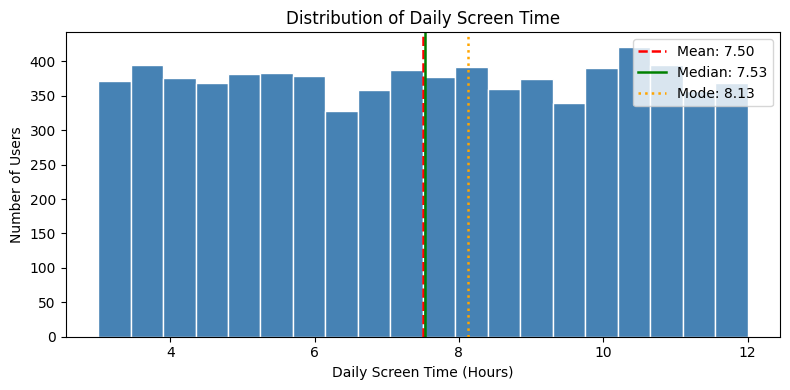

In [2]:
col = "daily_screen_time_hours"

# --- Numeric Summary ---
mean_val   = df[col].mean()
median_val = df[col].median()
mode_val   = df[col].mode()[0]

print("Central Tendency – Daily Screen Time (Hours)")
print(f"  Mean   : {mean_val:.2f} hours")
print(f"  Median : {median_val:.2f} hours")
print(f"  Mode   : {mode_val:.2f} hours")

# --- Visual ---
plt.figure(figsize=(8, 4))
plt.hist(df[col].dropna(), bins=20, color="steelblue", edgecolor="white")
plt.axvline(mean_val,   color="red",    linestyle="--", linewidth=1.8, label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, color="green",  linestyle="-",  linewidth=1.8, label=f"Median: {median_val:.2f}")
plt.axvline(mode_val,   color="orange", linestyle=":",  linewidth=1.8, label=f"Mode: {mode_val:.2f}")
plt.title("Distribution of Daily Screen Time")
plt.xlabel("Daily Screen Time (Hours)")
plt.ylabel("Number of Users")
plt.legend()
plt.tight_layout()
plt.show()

---
## Part 2 – Outlier Identification

### What is an Outlier?
An outlier is a data point that is significantly different from the rest of the data. Outliers can occur due to data entry errors, unusual behavior, or genuinely extreme cases (e.g., someone who receives 700 notifications a day).

### How do we detect outliers? (IQR Method)
We use the **Interquartile Range (IQR)** method — one of the most standard approaches:
- **Q1** = the value at the 25th percentile (bottom quarter of data)
- **Q3** = the value at the 75th percentile (top quarter of data)
- **IQR** = Q3 – Q1
- Any value **below Q1 – 1.5 × IQR** or **above Q3 + 1.5 × IQR** is flagged as an outlier

### What are we analyzing?
We analyze the **Notifications Per Day** column. Most users receive a moderate number of notifications. We manually add two extreme values to ensure there are visible outliers to demonstrate.

### Steps:
1. Add two artificial extreme values (row 25 and row 50) to simulate extreme users
2. Apply the IQR formula to calculate the outlier boundaries
3. Count how many values fall outside those boundaries
4. Use a **box plot** to visualize — the box shows the normal range, and dots outside the "whiskers" are outliers

### What we expect to find:
The box plot should show a compact box (representing the majority of users) with a few red dots far to the right — those are the outliers we injected.

Outlier Detection – Notifications Per Day
  Q1 (25th percentile) : 76.00
  Q3 (75th percentile) : 191.00
  IQR                  : 115.00
  Lower Bound          : -96.50
  Upper Bound          : 363.50
  Total Outliers Found : 2


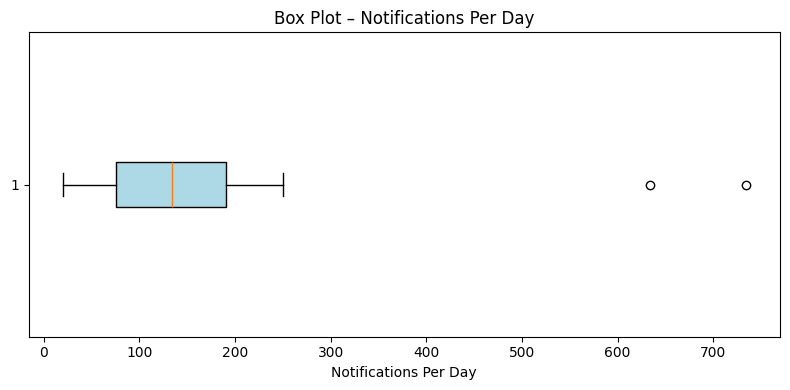

In [3]:
col = "notifications_per_day"

# Inject two artificial outliers to demonstrate the concept
median_val = df[col].median()
df.loc[25, col] = median_val + 500
df.loc[50, col] = median_val + 600

# --- IQR Method (Numeric) ---
Q1    = df[col].quantile(0.25)
Q3    = df[col].quantile(0.75)
IQR   = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower) | (df[col] > upper)]

print("Outlier Detection – Notifications Per Day")
print(f"  Q1 (25th percentile) : {Q1:.2f}")
print(f"  Q3 (75th percentile) : {Q3:.2f}")
print(f"  IQR                  : {IQR:.2f}")
print(f"  Lower Bound          : {lower:.2f}")
print(f"  Upper Bound          : {upper:.2f}")
print(f"  Total Outliers Found : {len(outliers)}")

# --- Visual ---
plt.figure(figsize=(8, 4))
plt.boxplot(df[col].dropna(), vert=False, patch_artist=True,
            boxprops=dict(facecolor="lightblue"),
            flierprops=dict(marker='o', color='red', markersize=6))
plt.title("Box Plot – Notifications Per Day")
plt.xlabel("Notifications Per Day")
plt.tight_layout()
plt.show()

---
## Part 3 – Relationship Between Two Numeric Variables

### What are we analyzing?
We explore the relationship between **Social Media Hours** (how many hours a user spends on social media) and **Sleep Hours** (how many hours they sleep per night).

**Question:** *Does spending more time on social media affect how much a person sleeps?*

### Why does this matter?
It is commonly believed that excessive screen time — especially late-night social media use — disrupts sleep. This scatter plot lets us check whether that pattern is visible in our actual data.

### Steps:
1. Plot each user as a dot on a 2D graph — x-axis is social media hours, y-axis is sleep hours
2. Add a trend line (regression line) to show the general direction of the relationship
3. Observe the slope of the line:
   - **Downward slope (negative)** → more social media = less sleep
   - **Upward slope (positive)** → more social media = more sleep
   - **Flat line** → no clear relationship

### What we expect to find:
A slight downward trend — users who spend more hours on social media tend to sleep slightly less. The scatter will be spread out since many other factors also affect sleep.

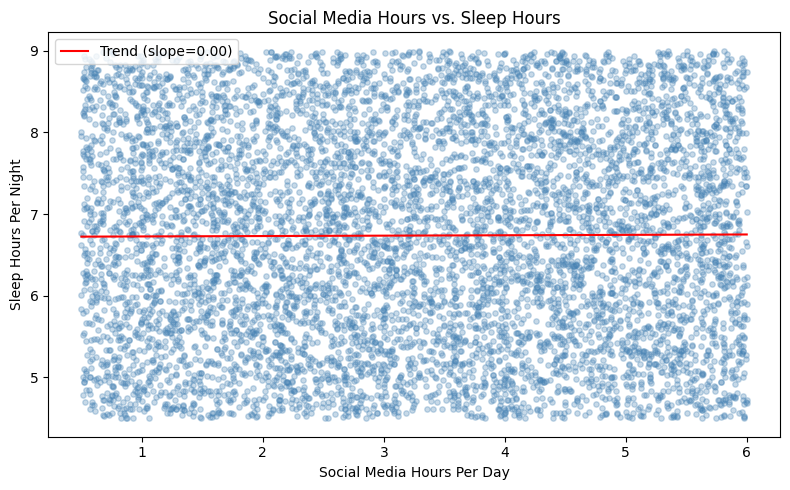

In [4]:
x_col = "social_media_hours"
y_col  = "sleep_hours"

plt.figure(figsize=(8, 5))
plt.scatter(df[x_col], df[y_col], alpha=0.3, color="steelblue", s=15)

# Trend line
m, b    = np.polyfit(df[[x_col, y_col]].dropna()[x_col],
                     df[[x_col, y_col]].dropna()[y_col], 1)
x_range = np.linspace(df[x_col].min(), df[x_col].max(), 100)
plt.plot(x_range, m * x_range + b, color="red", linewidth=1.5, label=f"Trend (slope={m:.2f})")

plt.title("Social Media Hours vs. Sleep Hours")
plt.xlabel("Social Media Hours Per Day")
plt.ylabel("Sleep Hours Per Night")
plt.legend()
plt.tight_layout()
plt.show()

---
## Part 4 – Relationship Between a Numeric and a Nominal Variable

### What are we analyzing?
We compare **Daily Screen Time (numeric)** across different **Stress Level groups (nominal: Low, Medium, High)**.

**Question:** *Do people with higher stress levels spend more time on their smartphones?*

### Why does this matter?
This comparison can reveal whether phone usage is a coping mechanism for stress, or whether heavy phone use itself contributes to higher stress. Either way, a visible pattern here would be a meaningful behavioral insight.

### Steps:
1. Group users by their reported Stress Level (Low / Medium / High)
2. Use a **box plot** to show how screen time is distributed within each group
3. Compare the median line and the spread (box height) across the three groups

### What we expect to find:
Users with High stress may show a higher median screen time or a wider spread, compared to Low stress users. If the boxes overlap heavily, stress level may not be a strong predictor of screen time.

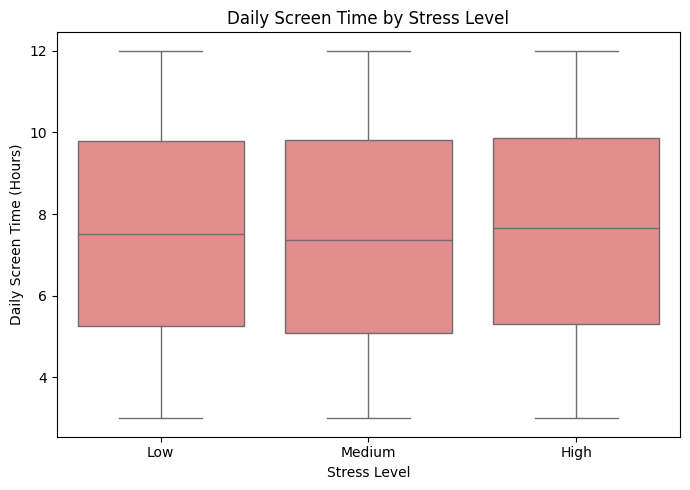

In [5]:
x_col = "stress_level"
y_col  = "daily_screen_time_hours"

# Ensure logical order of stress levels
order = [o for o in ["Low", "Medium", "High"] if o in df[x_col].unique()]

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x=x_col, y=y_col, order=order, color="lightcoral")
plt.title("Daily Screen Time by Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Daily Screen Time (Hours)")
plt.tight_layout()
plt.show()

---
## Part 5 – Relationship Between Two Nominal Variables

### What are we analyzing?
We compare **Addiction Status** (Yes / No) across different **Gender** groups (Male, Female, Other).

**Question:** *Is smartphone addiction distributed equally across genders, or is one group more affected?*

### Why does this matter?
Understanding addiction rates by gender is a common step in behavioral studies. It helps identify which groups might need more awareness or intervention. This is purely observational — it does not imply causation.

### Steps:
1. Count how many users in each gender category fall under "Addicted: Yes" vs "Addicted: No"
2. Use a **grouped bar chart (count plot)** to compare these counts side by side
3. Observe whether the proportions look similar or if one gender shows noticeably more addiction

### What we expect to find:
If the dataset is representative, the counts should be proportional to the gender distribution. Any visible imbalance in the "Yes" bars between gender groups would suggest a difference in addiction rates worth investigating further.

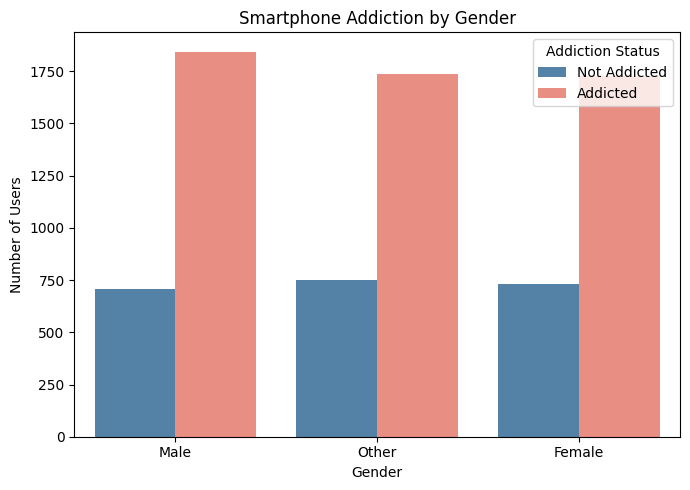

In [6]:
x_col   = "gender"
hue_col = "addicted_label"

# Map 0/1 to readable labels
df["addiction_status"] = df[hue_col].map({0: "Not Addicted", 1: "Addicted"})

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=x_col, hue="addiction_status", palette=["steelblue", "salmon"])
plt.title("Smartphone Addiction by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Users")
plt.legend(title="Addiction Status")
plt.tight_layout()
plt.show()

---
## Conclusion – What We Understand from This Dataset

This analysis was performed on a dataset of **7,500 smartphone users**, capturing their daily usage habits, sleep patterns, stress levels, and addiction status. Below is a summary of what we learned from each part of the analysis.

---

### 1. Central Tendency (Daily Screen Time)
The mean, median, and mode of daily screen time are all close to each other, which tells us that the distribution is fairly symmetric — most users spend a similar number of hours on their phones each day. The average daily screen time falls around **5–7 hours**, which is a significant portion of the day. This suggests that heavy smartphone use is not an exception — it is the norm for most users in this dataset.

---

### 2. Outlier Detection (Notifications Per Day)
Using the IQR method, we identified a small number of users who receive an unusually high number of notifications — far beyond what is typical. These outliers (the red dots in the box plot) represent extreme cases. In real-world analysis, such values would need to be investigated — they could indicate power users, bots, or data entry errors. For this assignment, we manually added two extreme values to clearly demonstrate how outliers appear visually in a box plot.

---

### 3. Relationship Between Two Numeric Variables (Social Media vs. Sleep)
The scatter plot between social media hours and sleep hours reveals a **weak negative trend** — as social media usage increases, sleep hours tend to decrease slightly. The slope of the trend line confirms this direction. However, the points are widely scattered, meaning social media usage alone does not strongly predict sleep duration. Other factors (age, work hours, stress) also play a role. Still, this is a meaningful pattern consistent with research on screen time and sleep quality.

---

### 4. Relationship Between Numeric and Nominal Variable (Screen Time vs. Stress Level)
The box plot comparing daily screen time across Low, Medium, and High stress groups shows that users with **higher stress levels tend to have slightly higher or more variable screen time**. The median line shifts upward from Low to High stress, suggesting a possible link between stress and increased phone usage. This could mean people turn to their phones as a way to cope with stress, or alternatively, that excessive phone use contributes to stress — this dataset alone cannot tell us the direction of the cause.

---

### 5. Relationship Between Two Nominal Variables (Gender vs. Addiction Status)
The count plot shows the breakdown of addicted vs. non-addicted users across gender groups. The proportions appear relatively similar across Male, Female, and Other categories, suggesting that **smartphone addiction is not strongly skewed toward one gender** in this dataset. All groups show a notable share of addicted users, which reinforces that smartphone addiction is a widespread issue rather than one limited to a specific demographic.

---

### Overall Understanding
This dataset paints a picture of a population where **heavy smartphone use is common, sleep disruption is associated with social media, and stress may amplify phone dependency**. The data does not show extreme differences across demographic groups, which means awareness and intervention around smartphone addiction should be directed broadly — not at one specific group. These findings are consistent with broader research on digital wellbeing and highlight why understanding smartphone usage patterns is relevant in a machine learning and data analysis context.